
================ FITS FILE STRUCTURE ================

Filename: C:\Users\mnncs\Downloads\flare stuff\go1520140329.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      25   ()      
  1  EDGES         1 BinTableHDU     18   1R x 1C   [4E]   
  2  FLUXES        1 BinTableHDU     32   1R x 2C   [42188D, 84376E]   
  3  STATUS        1 BinTableHDU     30   1R x 2C   [1E, 2E]   

================ AVAILABLE COLUMNS ==================

ColDefs(
    name = 'TIME'; format = '42188D'; unit = 's'
    name = 'FLUX'; format = '84376E'; unit = 'W /m**2'; dim = '(2,42188)'
)


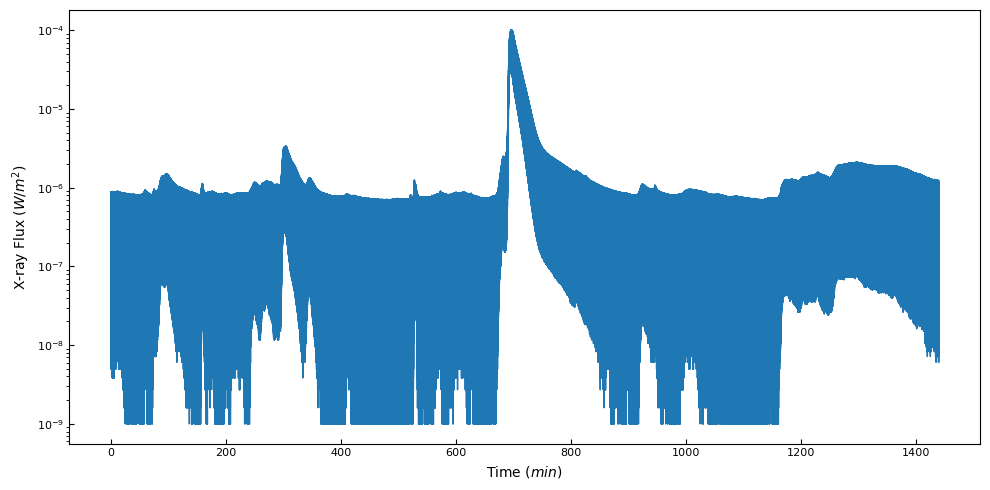


Flare peak index: 20410
Flare peak time (minutes): 696.6448166648547


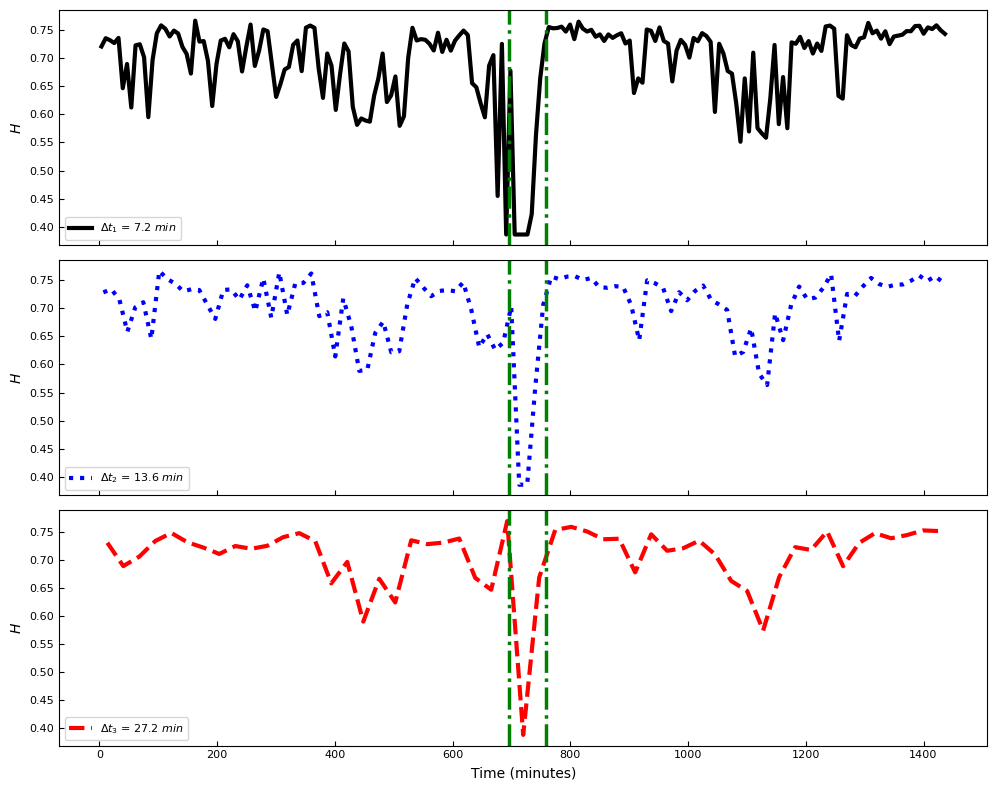

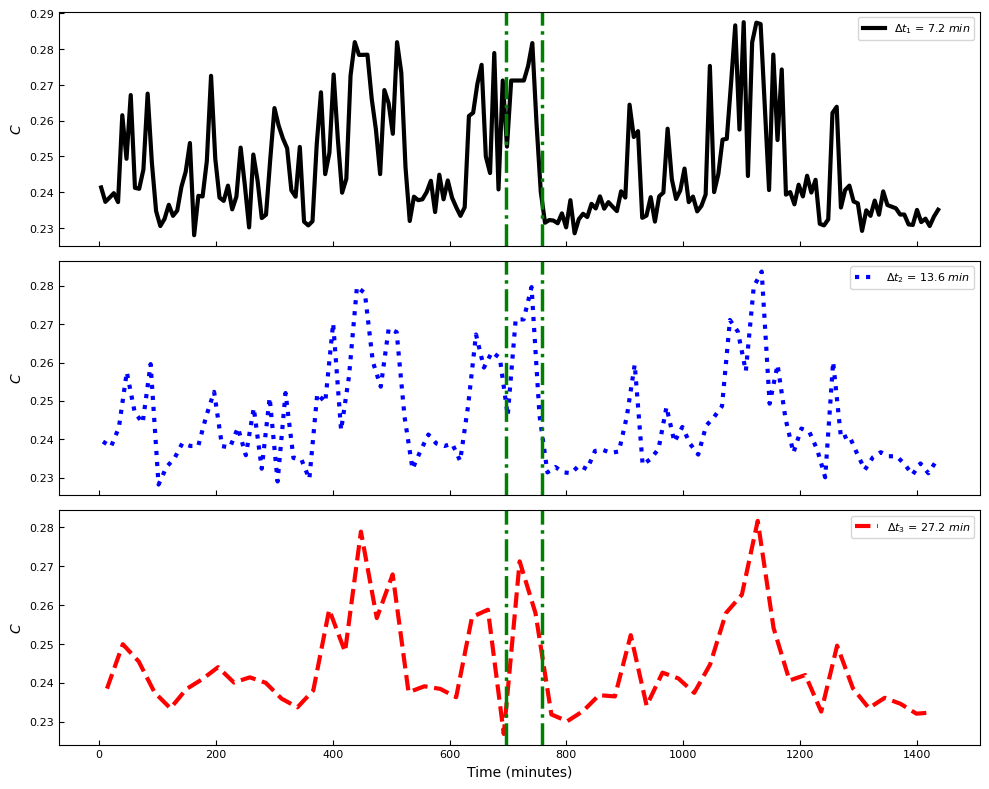

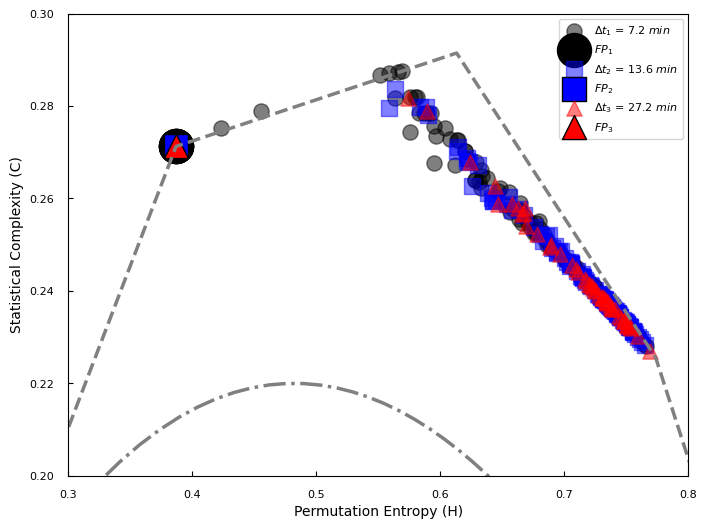

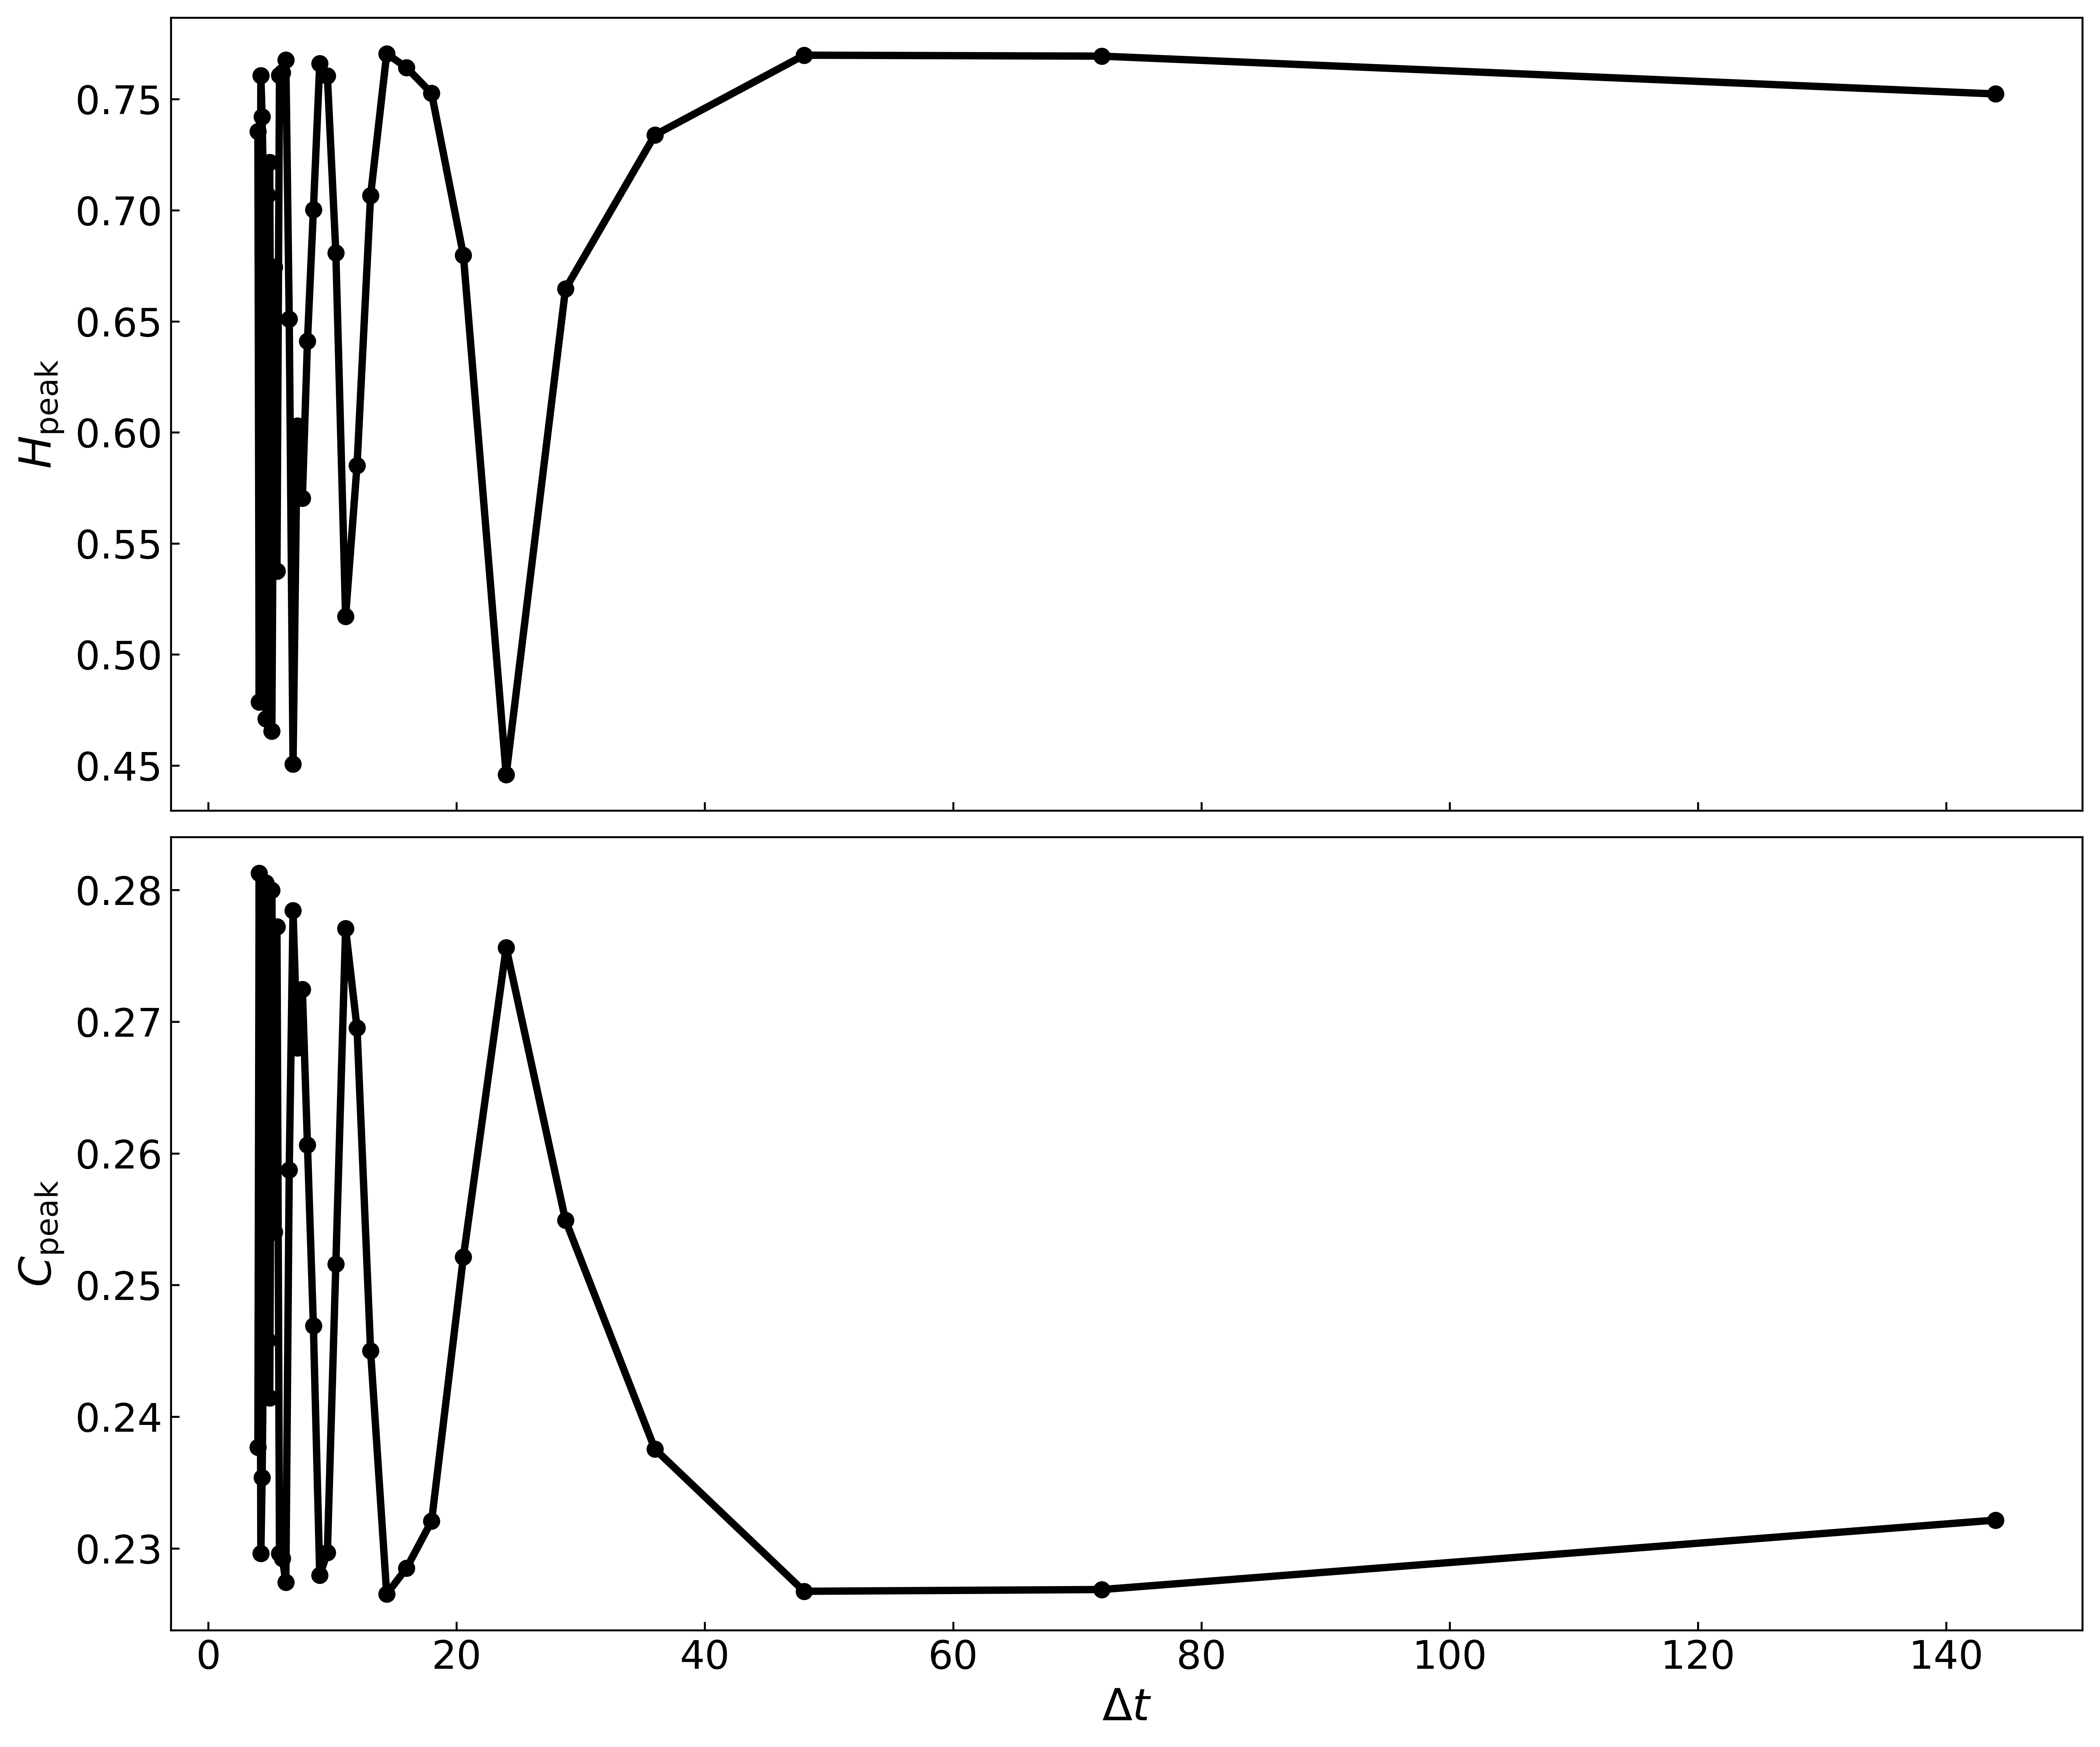

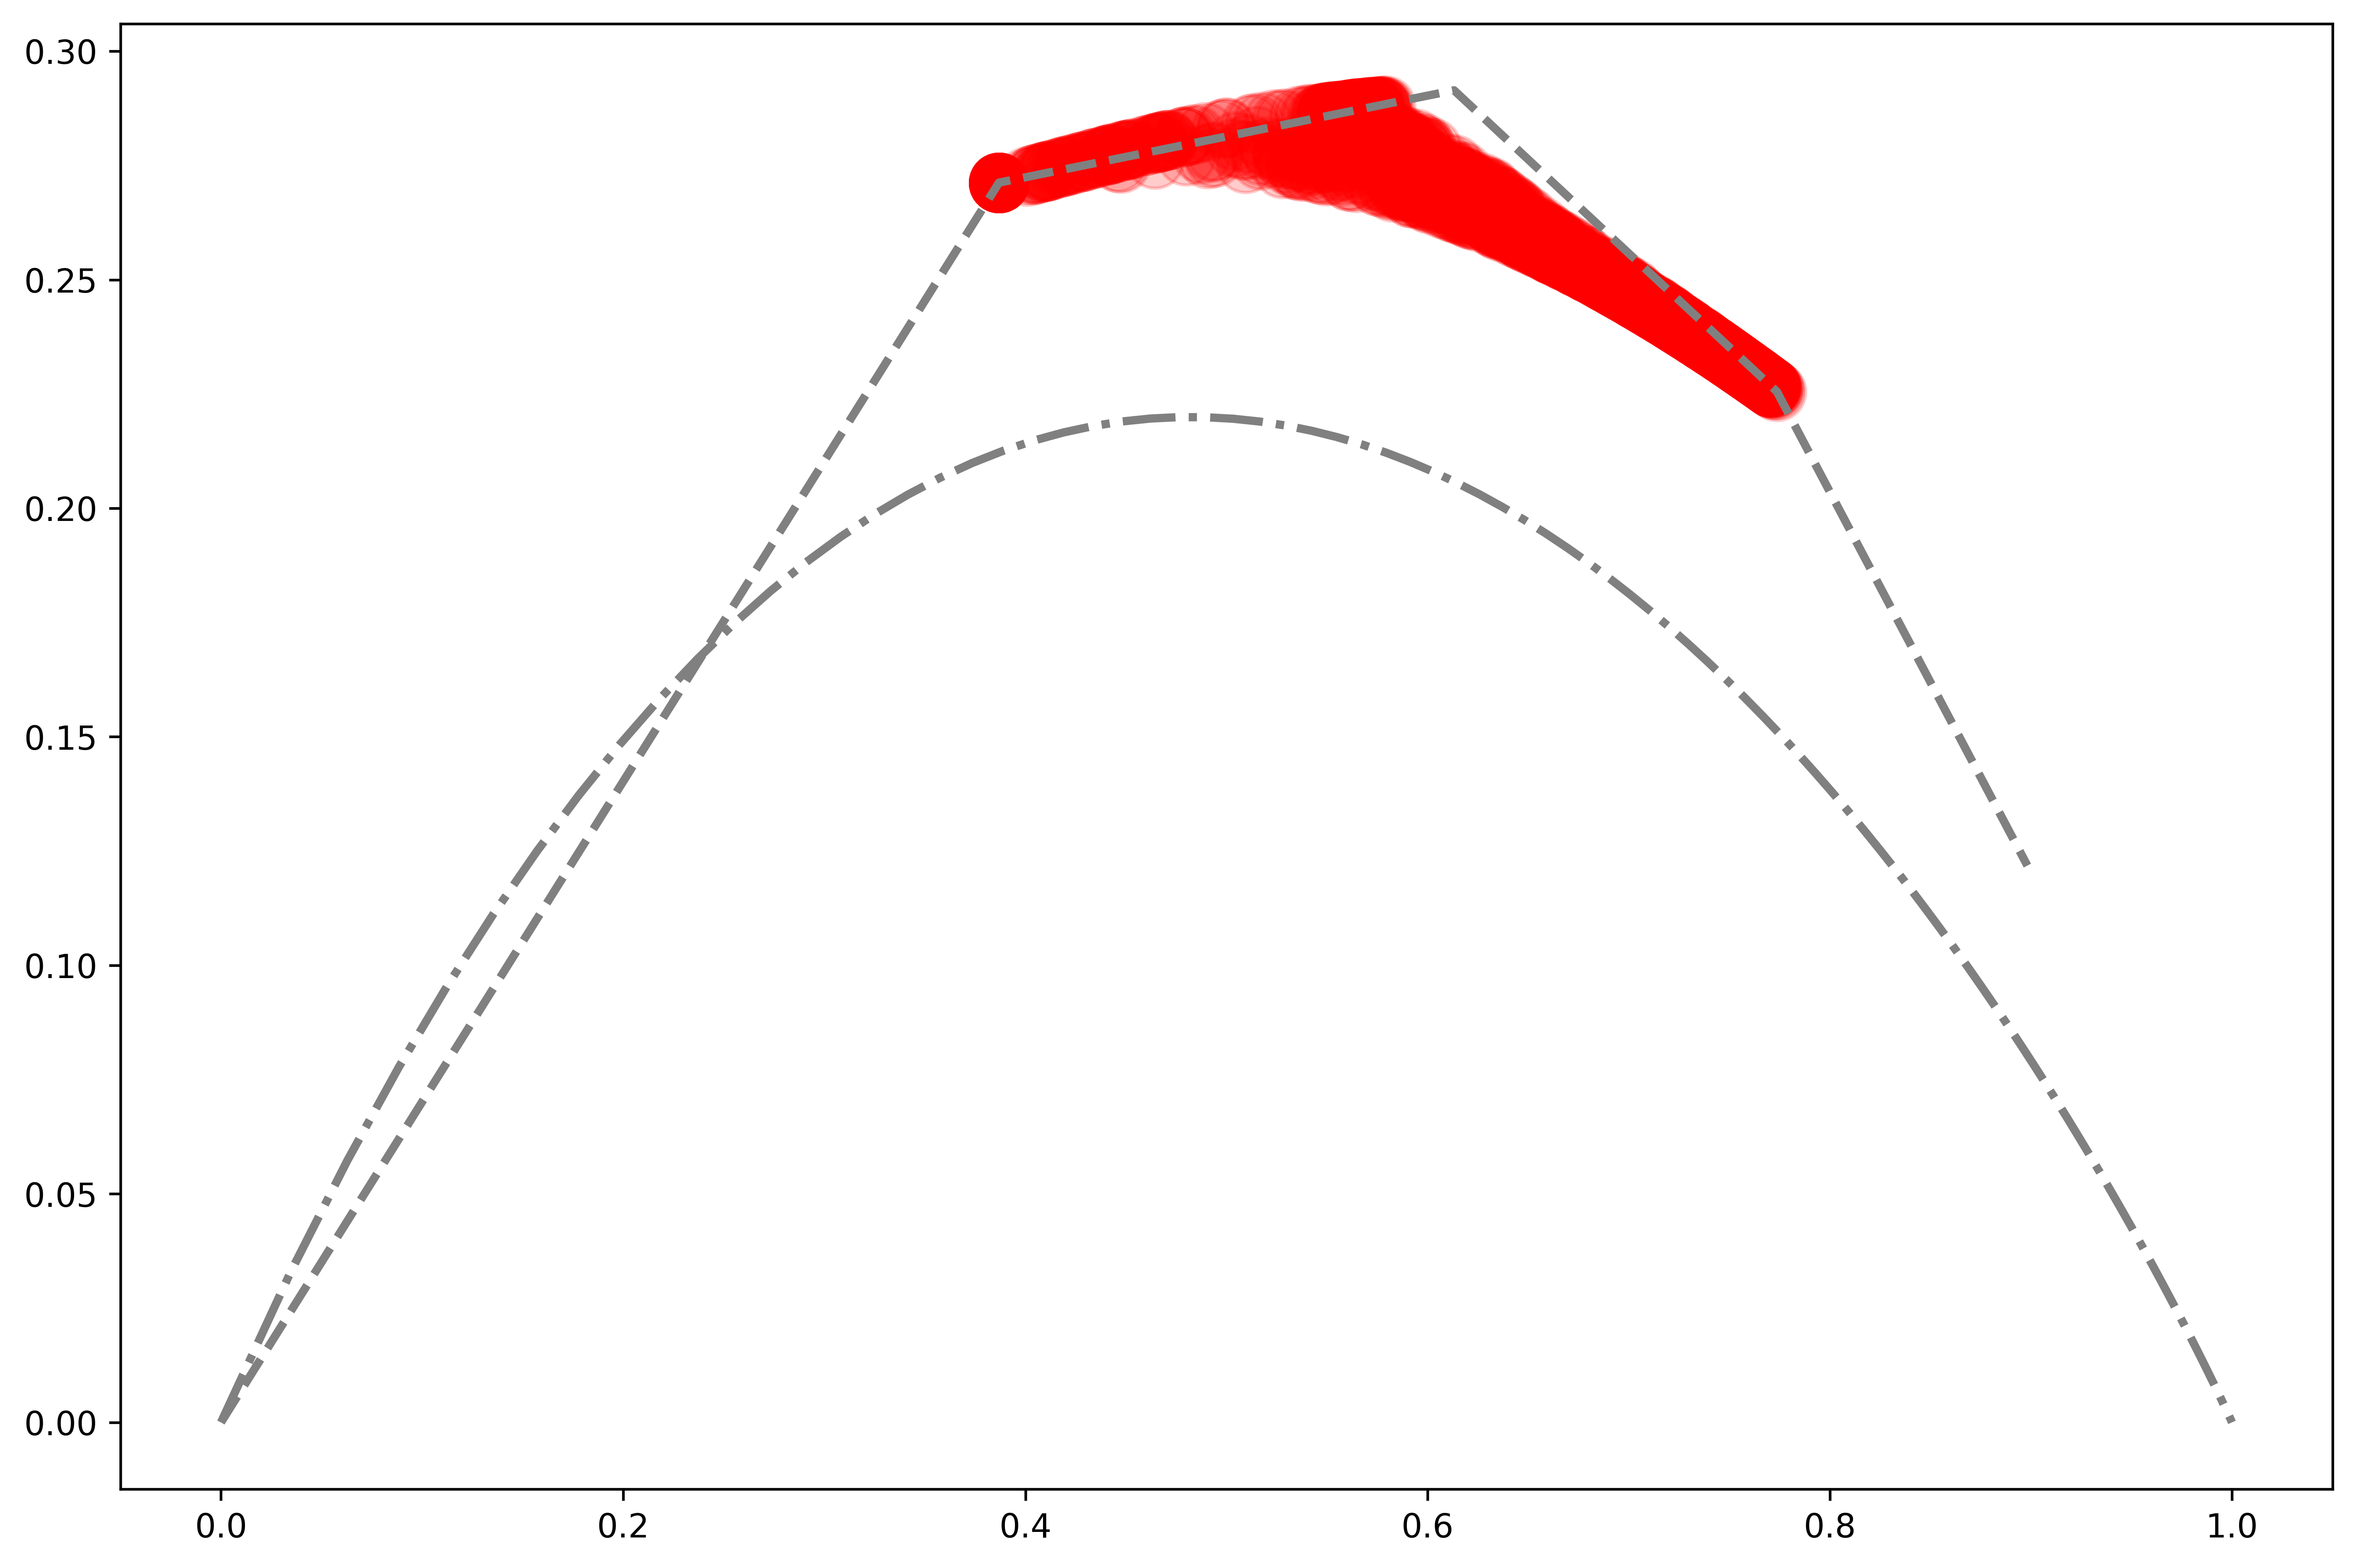

In [2]:
import numpy as np
import pandas as pd
from ordpy import complexity_entropy, maximum_complexity_entropy, minimum_complexity_entropy
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

# change if necessary
file_path = r"C:\Users\mnncs\Downloads\flare stuff\go1520140329.fits"

hdul = fits.open(file_path)

print("\n================ FITS FILE STRUCTURE ================\n")
hdul.info()

data = hdul[2].data

print("\n================ AVAILABLE COLUMNS ==================\n")
print(data.columns)

time = data[0][0]      # time vector
flux = data[0][1]      # combined flux vector

# Convert to numpy arrays
time = np.array(time)/60
flux = np.array(flux)

# flux contains two channels stacked together
flux = flux.reshape(2, -1)

xrsa = flux[0]     # 0.5–4 Å channel
xrsb = flux[1]     # 1–8 Å channel (standard flare flux)

signal = xrsb

mask = np.isfinite(signal)

time = time[mask]
signal = signal[mask]

# log scaling because solar flux spans many orders
signal_log = np.log10(signal)

# normalization for entropy / complexity analysis
signal_norm = (signal_log - np.mean(signal_log)) / np.std(signal_log)

# Create dataframe
df = pd.DataFrame({
    "time": time,
    "flux_norm": signal_norm
})

# Save to CSV
df.to_csv("go1520140329_timeseries.csv", index=False)

plt.figure(figsize=(10, 5), dpi=100)
plt.plot(time, signal, lw=1)
plt.yscale("log")
plt.xlabel(r"Time ($\mathit{min}$)", fontsize=10)
plt.ylabel(r"X-ray Flux $(\mathit{W}/\mathit{m}^2)$", fontsize=10)
plt.tick_params(axis='both', labelsize=8, direction='in')
plt.tight_layout()
plt.show()

hdul.close()

dx = 3
tau = 1

# window sizes that divide 42188 exactly
window_list = [212, 398, 796]
detection_indices = {
    212: (97, 100),
    398: (52, 53),
    796: (26, 26)
}

colors = ['k', 'blue', 'red']
linestyle = ['-', ':', '--']
markers = ['o', 's', '^']

dt = np.mean(np.diff(time))

peak_index = np.argmax(signal_norm)

print("\nFlare peak index:", peak_index)
print("Flare peak time (minutes):", time[peak_index])


def segment_ch(series, window, dx=3, tau=1):

    pe_values = []
    sc_values = []

    n_segments = len(series) // window

    for i in range(n_segments):

        start = i * window
        end = start + window

        segment = series[start:end]

        pe, sc = complexity_entropy(segment, dx=dx, taux=tau, tauy=tau)

        pe_values.append(pe)
        sc_values.append(sc)

    return np.array(pe_values), np.array(sc_values)


results = {}

for window_pe in window_list:

    pe_seg, sc_seg = segment_ch(signal_norm, window_pe, dx, tau)

    time_pe = (np.arange(len(pe_seg)) + 0.5) * window_pe * dt

    results[window_pe] = (time_pe, pe_seg, sc_seg)

# =====================================================
# PERMUTATION ENTROPY PLOT (3 VERTICAL SUBPLOTS)
# =====================================================

fig, axes = plt.subplots(3, 1, figsize=(10, 8), dpi=100, sharex=True)

for i, window_pe in enumerate(window_list):

    time_pe, pe_seg, sc_seg = results[window_pe]

    axes[i].plot(time_pe, pe_seg,
                 color=colors[i],
                 ls=linestyle[i],
                 lw=3,
                 label=rf'$\Delta t_{{{i+1}}}$ = {(window_pe*dt):.1f} $\mathit{{min}}$')

    axes[i].axvline(x=time[peak_index],
                    color='green',
                    linestyle='-.',
                    linewidth=2.5)
    axes[i].axvline(x=time[peak_index+1800],
                    color='green',
                    linestyle='-.',
                    linewidth=2.5)

    axes[i].set_ylabel(r"$H$", fontsize=10)
    axes[i].tick_params(axis='both', labelsize=8, direction='in')
    axes[i].legend(fontsize=8)

axes[2].set_xlabel("Time (minutes)", fontsize=10)

plt.tight_layout()
plt.show()

# =====================================================
# STATISTICAL COMPLEXITY PLOT
# =====================================================

fig, axes = plt.subplots(3, 1, figsize=(10, 8), dpi=100, sharex=True)

for i, window_pe in enumerate(window_list):

    time_pe, pe_seg, sc_seg = results[window_pe]

    axes[i].plot(time_pe, sc_seg,
                 color=colors[i],
                 ls=linestyle[i],
                 lw=3,
                 label=rf'$\Delta t_{{{i+1}}}$ = {(window_pe*dt):.1f} $\mathit{{min}}$')

    axes[i].axvline(x=time[peak_index],
                    color='green',
                    linestyle='-.',
                    linewidth=2.5)
    axes[i].axvline(x=time[peak_index+1800],
                    color='green',
                    linestyle='-.',
                    linewidth=2.5)

    axes[i].set_ylabel(r"$C$", fontsize=10)
    axes[i].tick_params(axis='both', labelsize=8, direction='in')
    axes[i].legend(fontsize=8)

axes[2].set_xlabel("Time (minutes)", fontsize=10)

plt.tight_layout()
plt.show()

# =====================================================
# CH PLANE
# =====================================================

plt.figure(figsize=(8, 6), dpi=100)

hmax, cmax = maximum_complexity_entropy(dx=dx).T
hmin, cmin = minimum_complexity_entropy(dx=dx).T

plt.plot(hmax, cmax, linestyle='--', color='gray', lw=2.5)
plt.plot(hmin, cmin, linestyle='-.', color='gray', lw=2.5)

for i, window_pe in enumerate(window_list):

    time_pe, pe_seg, sc_seg = results[window_pe]

    plt.scatter(pe_seg, sc_seg,
                color=colors[i],
                marker=markers[i],
                s=120,
                label=rf'$\Delta t_{{{i+1}}}$ = {(window_pe*dt):.1f} $\mathit{{min}}$',
                alpha=0.5)

    i1, i2 = detection_indices[window_pe]

    plt.scatter(pe_seg[i1:i2+1], sc_seg[i1:i2+1],
                s=600 if i == 0 else 300, marker=markers[i], edgecolor='black', color=colors[i],
                label=rf'$FP_{i+1}$')

plt.xlabel("Permutation Entropy (H)", fontsize=10)
plt.ylabel("Statistical Complexity (C)", fontsize=10)
plt.tick_params(axis='both', labelsize=8, direction='in', pad=10)
plt.xlim(0.3, 0.8)
plt.ylim(0.2, 0.3)
plt.legend(fontsize=8)

plt.show()
import pandas as pd
from ordpy import complexity_entropy, maximum_complexity_entropy, minimum_complexity_entropy
import numpy as np
import matplotlib.pyplot as plt

file_1 = "go1520140329_timeseries.csv"

df_1 = pd.read_csv(file_1)

signal_norm_1 = df_1["flux_norm"].values
time_1 = df_1["time"].values

dx = 3
tau = 1

dt = np.mean(np.diff(time_1))
window_list = []
for n in range(1,37):
    window_list.append(int(1440//(10*n*dt)))

# =====================================================
# 2. SEGMENT FUNCTION
# =====================================================

def segment_ch(series, window, dx=3, tau=1):

    pe_values = []
    sc_values = []

    n_segments = len(series) // window

    for i in range(n_segments):

        start = i * window
        end   = start + window

        segment = series[start:end]

        pe, sc = complexity_entropy(segment, dx=dx, taux=tau, tauy=tau)

        pe_values.append(pe)
        sc_values.append(sc)

    return np.array(pe_values), np.array(sc_values)

# =====================================================
# 3. COMPUTE PE & SC FOR ALL WINDOWS
# =====================================================

results = {}

for window_pe in window_list:

    pe_seg, sc_seg = segment_ch(signal_norm_1, window_pe, dx, tau)

    time_pe = (np.arange(len(pe_seg)) + 0.5) * window_pe * dt

    results[window_pe] = (time_pe, pe_seg, sc_seg)

# =====================================================
# 4. AUTOMATIC DETECTION REGION
# =====================================================

H_noise_list = []
H_peak_list = []
delta_H_list = []
C_noise_list = []
C_peak_list = []
delta_C_list = []

for window_pe in window_list:

    time_pe, pe_seg, sc_seg = results[window_pe]

    # =====================================================
    # FIND SEGMENT CLOSEST TO FLARE PEAK
    # =====================================================

    peak_index = np.argmin(np.abs(time_pe - 696.645))

    # entropy and complexity at flare peak
    H_peak = pe_seg[peak_index]
    C_peak = sc_seg[peak_index]

    # indices excluding the peak
    noise_indices = np.delete(np.arange(len(pe_seg)), peak_index)

    # =====================================================
    # NOISE ESTIMATES
    # =====================================================

    H_noise = np.mean(pe_seg[noise_indices])
    H_noise_list.append(H_noise)

    C_noise = np.mean(sc_seg[noise_indices])
    C_noise_list.append(C_noise)

    # =====================================================
    # PEAK VALUES
    # =====================================================

    H_peak_list.append(H_peak)
    C_peak_list.append(C_peak)


# =====================================================
# 5. SCALING ANALYSIS
# =====================================================

delta_t = np.array(window_list) * dt

fig, ax = plt.subplots(2, 1, figsize=(12,10), dpi=600, sharex=True)

# --- H_min ---
ax[0].plot(delta_t, H_peak_list, 'o-', lw=3, color='k')
ax[0].set_ylabel(r"$H_{\mathrm{peak}}$", fontsize=18)
ax[0].tick_params(axis='both', labelsize=16, direction='in')

# --- C_min ---
ax[1].plot(delta_t, C_peak_list, 'o-', lw=3, color='k')
ax[1].set_xlabel(r"$\Delta t$", fontsize=18)
ax[1].set_ylabel(r"$C_{\mathrm{peak}}$", fontsize=18)
ax[1].tick_params(axis='both', labelsize=16, direction='in')

plt.tight_layout()
plt.show()

# =====================================================
# CH PLANE
# =====================================================

plt.figure(figsize=(12,8), dpi=600)

hmax, cmax = maximum_complexity_entropy(dx=dx).T
hmin, cmin = minimum_complexity_entropy(dx=dx).T

plt.plot(hmax, cmax, linestyle='--', color='gray', lw=2.5)
plt.plot(hmin, cmin, linestyle='-.', color='gray', lw=2.5)

for i,window_pe in enumerate(window_list):

    time_pe, pe_seg, sc_seg = results[window_pe]

    plt.scatter(pe_seg, sc_seg,
                color='red',
                marker='o',
                s=300,
                alpha=0.2)


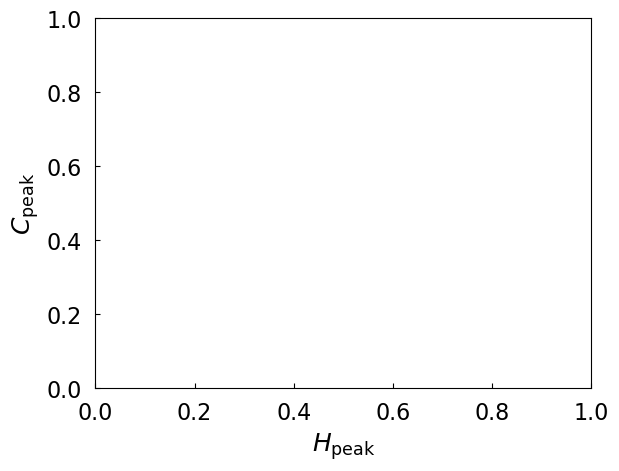

In [3]:

plt.xlabel(r"$H_{\mathrm{peak}}$", fontsize=18)
plt.ylabel(r"$C_{\mathrm{peak}}$", fontsize=18)

plt.tick_params(axis='both', labelsize=16, direction='in', pad=10)

plt.show()